In [71]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

from sklearn.preprocessing import LabelEncoder, StandardScaler

import xgboost as xgb
import joblib

In [72]:
data = pd.read_csv("dataset/final_coastal_dataset.csv")

data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.month
data["Rainfall_lag2"] = data["Rainfall"].shift(2)
data["Rainfall_lag3"] = data["Rainfall"].shift(3)

data = data.dropna()

print(data.head())

        Date    Rainfall  Sea_Level  Soil_Moisture  Rainfall_lag1  \
3 1998-06-30   28.041772     7055.0       3.988700      21.676685   
4 1998-07-31   84.962687     7055.0       4.983455      28.041772   
5 1998-08-31  134.570285     7055.0       5.575614      84.962687   
6 1998-09-30  133.236587     7055.0       5.476501     134.570285   
7 1998-10-31  215.872284     7055.0       5.725842     133.236587   

   Rainfall_3month_avg  Sea_Level_trend  Rainfall_lag2  Rainfall_lag3  
3            21.919706              0.0      16.040662       1.248927  
4            44.893715              0.0      21.676685      16.040662  
5            82.524915              0.0      28.041772      21.676685  
6           117.589853              0.0      84.962687      28.041772  
7           161.226385              0.0     134.570285      84.962687  


In [73]:
def classify_risk(sea_level):

    if sea_level < 7000:
        return "Low"

    elif 7000 <= sea_level <= 7200:
        return "Medium"

    else:
        return "High"


data["Flood_Risk"] = data["Sea_Level"].apply(classify_risk)

print(data[["Sea_Level","Flood_Risk"]].head())

   Sea_Level Flood_Risk
3     7055.0     Medium
4     7055.0     Medium
5     7055.0     Medium
6     7055.0     Medium
7     7055.0     Medium


In [74]:
print(data["Flood_Risk"].value_counts())

Flood_Risk
Medium    94
Low       94
High      11
Name: count, dtype: int64


In [75]:
le = LabelEncoder()

data["Flood_Risk_Label"] = le.fit_transform(data["Flood_Risk"])
data["Month"] = data["Date"].dt.month

print(le.classes_)

['High' 'Low' 'Medium']


In [76]:
X = data[[
    "Rainfall",
    "Soil_Moisture",
    "Rainfall_lag1",
    "Rainfall_lag2",
    "Rainfall_lag3",
    "Rainfall_3month_avg",
    "Sea_Level_trend",
    "Month"
]]

y = data["Flood_Risk_Label"]

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [78]:


rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_clf.fit(X_train, y_train)

rf_pred = rf_clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8


In [79]:
gb_clf = GradientBoostingClassifier()

gb_clf.fit(X_train, y_train)

gb_pred = gb_clf.predict(X_test)

print("Gradient Boost Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boost Accuracy: 0.775


In [80]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05
)

xgb_clf.fit(X_train, y_train)

xgb_pred = xgb_clf.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.775


In [81]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
lr_clf = LogisticRegression(max_iter=3000)

lr_clf.fit(X_train_scaled, y_train)

lr_pred = lr_clf.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.85


In [83]:
stack_clf = StackingClassifier(

    estimators=[
        ("rf", rf_clf),
        ("gb", gb_clf),
        ("xgb", xgb_clf)
    ],

    final_estimator=LogisticRegression()
)

stack_clf.fit(X_train, y_train)

stack_pred = stack_clf.predict(X_test)
stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))

print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))

Stacking Accuracy: 0.8


In [84]:
print(classification_report(y_test, stack_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.81      0.89      0.85        19
           2       0.79      0.79      0.79        19

    accuracy                           0.80        40
   macro avg       0.53      0.56      0.55        40
weighted avg       0.76      0.80      0.78        40



C:\Users\priya\PycharmProjects\Coastal-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\priya\PycharmProjects\Coastal-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\priya\PycharmProjects\Coastal-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

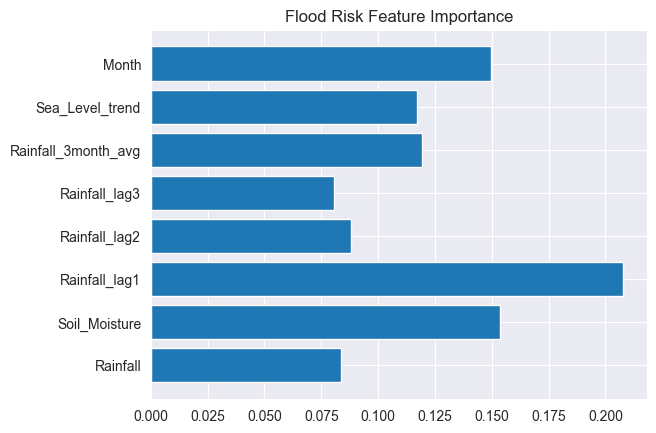

In [85]:
import matplotlib.pyplot as plt

importance = rf_clf.feature_importances_

features = X.columns

plt.barh(features, importance)

plt.title("Flood Risk Feature Importance")

plt.show()

In [86]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))

[[ 0  0  2]
 [ 0 18  1]
 [ 0  5 14]]


In [87]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
stack_model = StackingClassifier(

    estimators=[
        ("rf", rf_clf),
        ("gb", gb_clf),
        ("xgb", xgb_clf)
    ],

    final_estimator=LogisticRegression()
)
stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))

Stacking Accuracy: 0.8


In [88]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("rf", rf_clf),
        ("gb", gb_clf),
        ("xgb", xgb_clf)
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)

vote_pred = voting_model.predict(X_test)

print("Voting Accuracy:", accuracy_score(y_test, vote_pred))

Voting Accuracy: 0.775


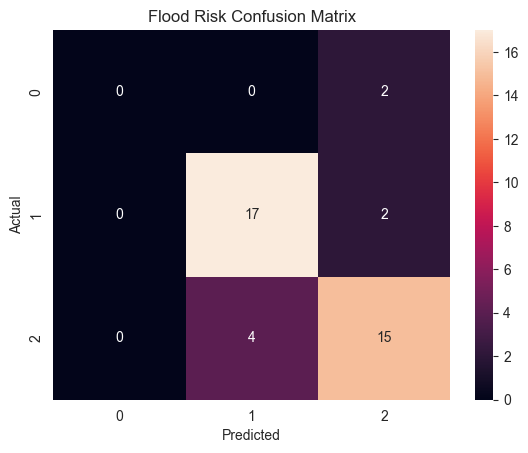

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, stack_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Flood Risk Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()